In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from data import DatasaurusDozen, Swissroll, sample_noise
from flow import flow_pair, sample_t, flow_matching_loss, sample_trajectory
from model import MLPVelocity

def plot_batch(batch):
    arr = batch.cpu().numpy()
    plt.scatter(arr[:, 0], arr[:, 1], marker='.')

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

# Data

Load 2D point data from [Datasaurus Dozen](https://jumpingrivers.github.io/datasauRus/) or Swissroll.

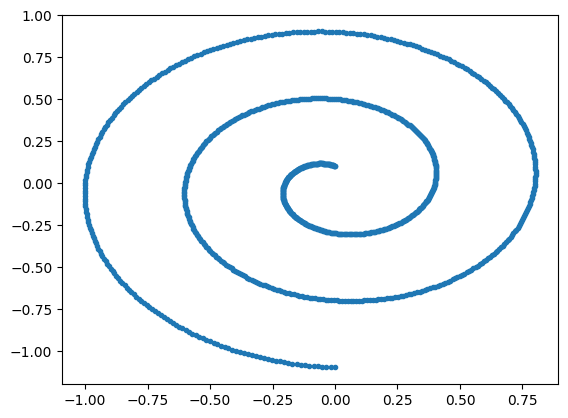

In [2]:
# dataset = DatasaurusDozen(dataset='dino')
dataset = Swissroll(np.pi/2, 5*np.pi, 1000)
loader = DataLoader(dataset, batch_size=len(dataset))
plot_batch(next(iter(loader)))

# Model

MLP that predicts velocity v(x_t, t). Input: x_t (2D) + time embedding (2D sin/cos) = 4D → output: 2D velocity.

In [3]:
device = torch.device('cpu')
model = MLPVelocity().to(device)

# Train

Flow matching: learn v_theta to match target velocity v = x1 - x0 along linear interpolation x_t = (1-t)x0 + tx1.

In [4]:
torch.manual_seed(42)
epochs = 15000
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
losses = []

for epoch in range(epochs):
    model.train()
    for x1_b in loader:
        x1_b = x1_b.to(device)
        x0 = sample_noise(x1_b.size(0), device=device)
        t = sample_t(x1_b.size(0), device)
        x_t, target_v = flow_pair(x0, x1_b, t)
        pred_v = model(x_t, t)
        loss = flow_matching_loss(pred_v, target_v)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

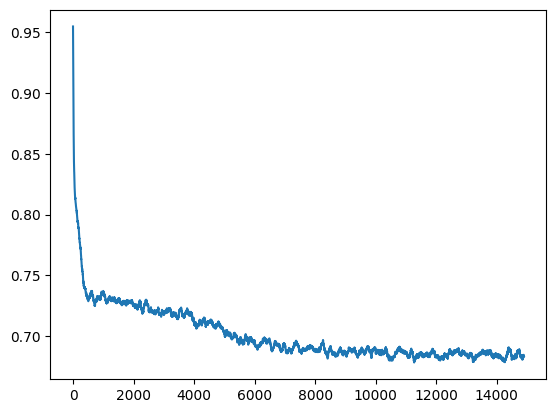

In [5]:
plt.plot(moving_average(losses, 100))
plt.show()

# Sample

Integrate ODE from Gaussian noise (t=0) to data (t=1) using learned velocity field.

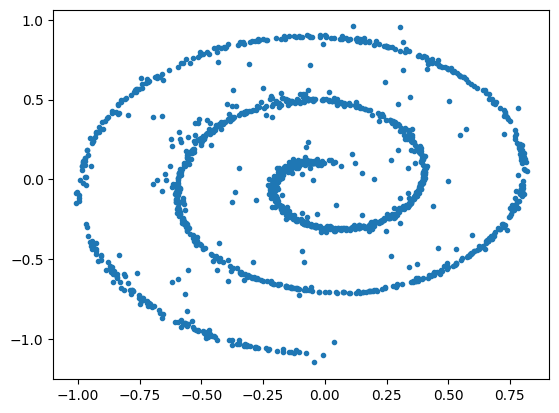

In [6]:
model.eval()
x0 = sample_noise(1500, device=device, seed=0)
traj = sample_trajectory(x0, lambda x, t: model(x, t), n_steps=80)
x1 = traj['xs'][-1]
plot_batch(x1)

# Save

Save the pre-trained unconditional backbone for fine-tuning with conditional information (see `finetune.ipynb`).

In [7]:
torch.save(model.state_dict(), 'pretrained_backbone.pt')

## Animation

Particle trajectories from $t=0$ (Gaussian noise) to $t=1$ under the learned velocity field, with a background quiver plot: arrow **length** is normalized for readability; **color** encodes $\|\mathbf{v}\|$ with a **fixed** scale using **log** normalization (2–99.8% over all times on the grid) and the **jet** colormap for strong hue separation. The last frame is **held** for ~2 s so the spiral at $t=1$ is easy to see. Requires a trained `model` or `pretrained_backbone.pt`.

In [10]:
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LogNorm

from model import MLPVelocity
from data import sample_noise
from flow import sample_trajectory

# --- academic style ---
mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Times", "serif"],
        "mathtext.fontset": "dejavuserif",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f8",
        "axes.edgecolor": "#2d2d2d",
        "axes.linewidth": 0.9,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

device = torch.device("cpu")
try:
    _net = model
except NameError:
    _net = MLPVelocity().to(device)
    _net.load_state_dict(torch.load("pretrained_backbone.pt", map_location=device))
_net.eval()

# --- trajectory & grid ---
n_particles = 720
n_steps = 80
lim = 1.28
ng = 17
seed_anim = 0

x0 = sample_noise(n_particles, device=device, seed=seed_anim)
with torch.no_grad():
    traj = sample_trajectory(x0, lambda x, t: _net(x, t), n_steps=n_steps)
xs = traj["xs"].cpu().numpy()
times = traj["times"].cpu().numpy().astype(np.float64)

gx = np.linspace(-lim, lim, ng)
gy = np.linspace(-lim, lim, ng)
GX, GY = np.meshgrid(gx, gy, indexing="xy")
grid_np = np.stack([GX.ravel(), GY.ravel()], axis=1).astype(np.float32)
grid_t = torch.from_numpy(grid_np).to(device)

# Precompute field on grid
all_U: list[np.ndarray] = []
all_V: list[np.ndarray] = []
all_spd: list[np.ndarray] = []
with torch.no_grad():
    for k in range(n_steps + 1):
        tk = float(times[k])
        tt = torch.full((grid_t.shape[0], 1), tk, device=device, dtype=torch.float32)
        v = _net(grid_t, tt).cpu().numpy()
        U = v[:, 0].reshape(ng, ng)
        Vv = v[:, 1].reshape(ng, ng)
        spd = np.hypot(U, Vv)
        all_U.append(U)
        all_V.append(Vv)
        all_spd.append(spd)

# Fixed global limits + log norm (stretches low speeds across jet hues)
spd_flat = np.concatenate([s.ravel() for s in all_spd])
spd_pos = spd_flat[spd_flat > 0]
if spd_pos.size == 0:
    v_lo, v_hi = 1e-4, 1.0
else:
    v_lo = float(np.percentile(spd_pos, 2))
    v_hi = float(np.percentile(spd_pos, 99.8))
    v_lo = max(v_lo, 1e-5)
    if v_hi <= v_lo * 1.01:
        v_hi = v_lo * 10.0

quiver_norm = LogNorm(vmin=v_lo, vmax=v_hi)

try:
    cmap = mpl.colormaps["jet"]
except (AttributeError, KeyError):
    cmap = mpl.cm.get_cmap("jet")

cell = (2 * lim) / max(ng - 1, 1)
arrow_len = 0.42 * cell

fig, ax = plt.subplots(figsize=(6.8, 6.2), dpi=128)
plt.subplots_adjust(left=0.1, right=0.88, top=0.92, bottom=0.1)

Q = ax.quiver(
    GX,
    GY,
    np.zeros_like(GX),
    np.zeros_like(GY),
    np.zeros_like(GX),
    cmap=cmap,
    norm=quiver_norm,
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.0028,
    headwidth=3.0,
    headlength=3.8,
    headaxislength=3.0,
    zorder=2,
    alpha=0.62,
)
scat = ax.scatter(xs[0, :, 0], xs[0, :, 1], s=7, c="#16213e", alpha=0.78, linewidths=0, zorder=4)

cbar = fig.colorbar(Q, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label(r"$\|\mathbf{v}(\mathbf{x}, t)\|$ (log scale)", rotation=270, labelpad=18)

pause_frames = 36


def _frame(i: int):
    i = int(i)
    k = n_steps if i > n_steps else i
    t = float(times[k])
    pos = xs[k]
    scat.set_offsets(pos)

    U, Vv, spd = all_U[k], all_V[k], all_spd[k]
    mag = np.hypot(U, Vv)
    U_n = U / (mag + 1e-9)
    V_n = Vv / (mag + 1e-9)
    spd_c = np.clip(spd, v_lo, v_hi)
    spd_c = np.maximum(spd_c, v_lo)
    Q.set_UVC(U_n * arrow_len, V_n * arrow_len, spd_c)

    if k == n_steps and i > n_steps:
        title = rf"Flow matching (pretrain): $t = 1.000$  (hold)"
    else:
        title = rf"Flow matching (pretrain): $t = {t:.3f}$"
    ax.set_title(title, pad=10)
    return (Q, scat)


ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.grid(True, color="#b8b8c0", linewidth=0.55, linestyle="--", alpha=0.75)
ax.set_axisbelow(True)

anim = FuncAnimation(
    fig,
    _frame,
    frames=n_steps + 1 + pause_frames,
    interval=55,
    blit=False,
)

out_path = "pretrain.gif"
writer = PillowWriter(fps=18)
anim.save(out_path, writer=writer, dpi=120)
plt.close(fig)
print(f"Saved: {out_path}")



Saved: pretrain.gif
